In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
pattern= "outputs/ddim_inference_experiment_results_S*_samples*.csv"

In [3]:
csv_files = glob.glob(pattern)

In [4]:
dfs= [pd.read_csv(file) for file in csv_files]

df_all = pd.concat(dfs, ignore_index=True)

df_all.to_csv("outputs/ddim_inference_experiment_results_all.csv", index=False)
print(df_all.columns)

Index(['denoising_steps', 'num_samples', 'inference_time_mins', 'nc_file',
       'SSIM_temp_DDIM', 'SSIM_precip_DDIM', 'CRPS_temp_DDIM',
       'CRPS_precip_DDIM', 'SSIM_temp_UNet', 'SSIM_precip_UNet',
       'CRPS_temp_UNet', 'CRPS_precip_UNet'],
      dtype='object')


In [77]:

def pareto_front_min(df, x_col, y_col):
    data = df[[x_col, y_col]].values
    is_pareto = np.ones(data.shape[0], dtype=bool)
    for i, point in enumerate(data):
        # If any other point is lower in both x and y, it's not Pareto optimal
        is_pareto[i] = not np.any(
            np.all(data < point, axis=1)
        )
    return is_pareto

def find_elbow(df, x_col, y_col):
    pareto_mask = pareto_front_min(df, x_col, y_col)
    pareto_points = df.loc[pareto_mask].sort_values(by=x_col)
    pts = pareto_points[[x_col, y_col]].values  # Only numeric columns
    if len(pts) < 2:
        return pareto_points.iloc[0]
    line_vec = pts[-1] - pts[0]
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vec_from_first = pts - pts[0]
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    proj = np.outer(scalar_proj, line_vec_norm)
    vec_to_line = vec_from_first - proj
    dists = np.linalg.norm(vec_to_line, axis=1)
    elbow_idx = np.argmax(dists)
    elbow_point = pareto_points.iloc[elbow_idx]
    return elbow_point

In [78]:
elbow_temp=find_elbow(df_all, "CRPS_temp_DDIM", "inference_time_mins").to_dict()
elbow_precip=find_elbow(df_all, "CRPS_precip_DDIM", "inference_time_mins").to_dict()

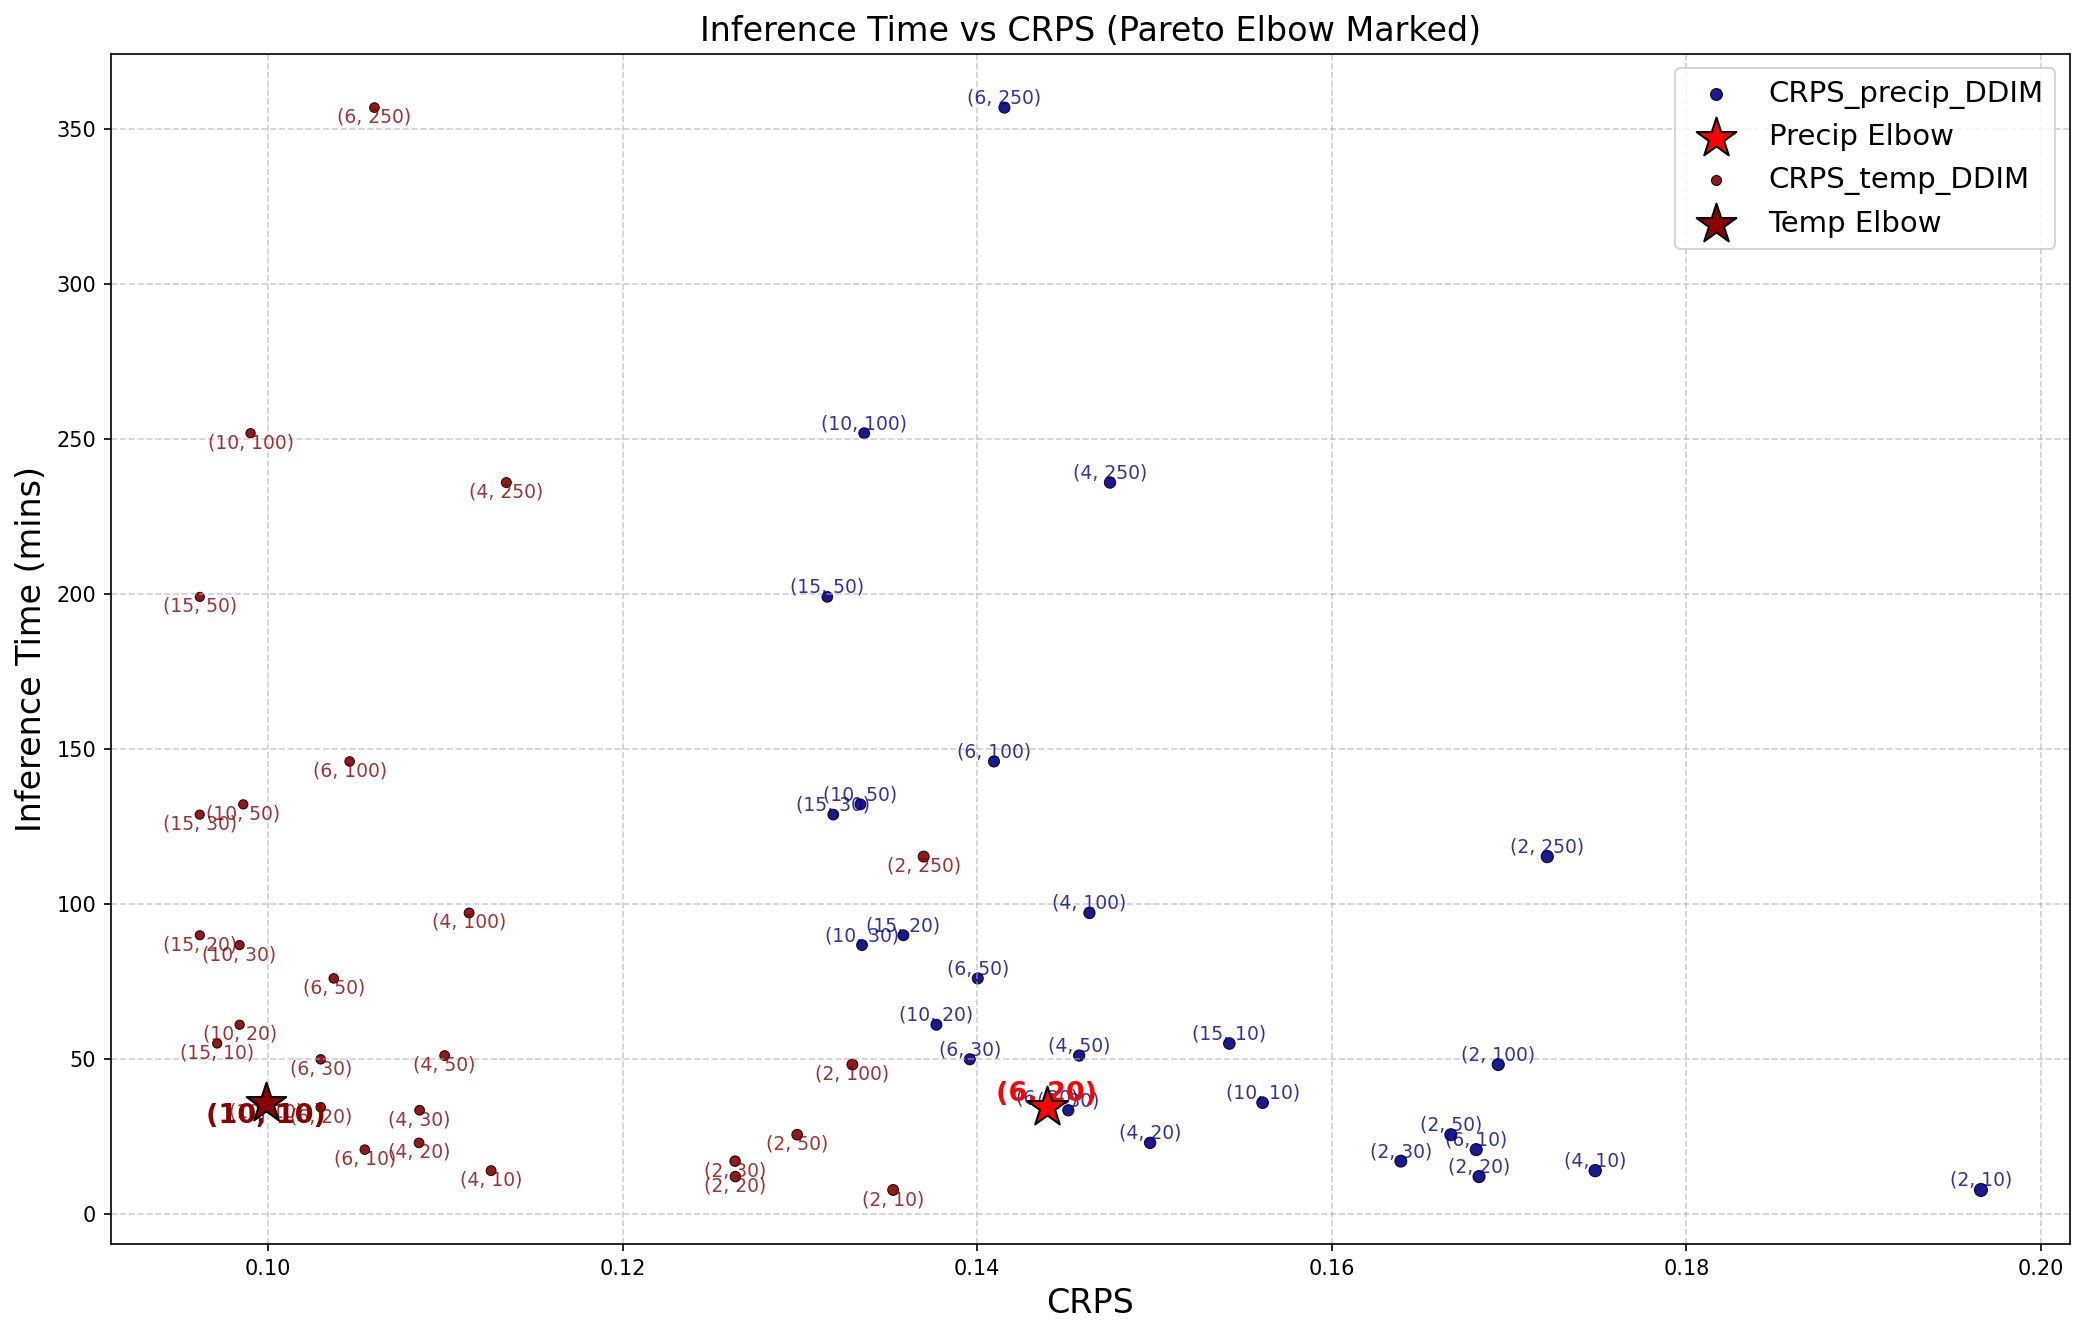

In [81]:
plt.figure(figsize=(14, 9), dpi=150)

# Precipitation (blue)
plt.scatter(
    df_all["CRPS_precip_DDIM"],
    df_all["inference_time_mins"],
    s=df_all["CRPS_precip_DDIM"] * 200,
    color='darkblue',
    alpha=0.9,
    edgecolor='k',
    linewidth=0.5,
    label='CRPS_precip_DDIM'
)
# Label each point with (num_samples, denoising_steps)
for i in range(len(df_all)):
    plt.text(
        df_all["CRPS_precip_DDIM"].iloc[i],
        df_all["inference_time_mins"].iloc[i] + 0.02,
        f"({int(df_all['num_samples'].iloc[i])}, {int(df_all['denoising_steps'].iloc[i])})",
        fontsize=9,
        color='darkblue',
        ha='center',
        va='bottom',
        alpha=0.8
    )

plt.scatter(
    elbow_precip["CRPS_precip_DDIM"],
    elbow_precip["inference_time_mins"],
    s=400,
    color='red',
    marker='*',
    edgecolor='k',
    label='Precip Elbow',
    zorder=10
)
plt.text(
    elbow_precip["CRPS_precip_DDIM"],
    elbow_precip["inference_time_mins"] + 0.03,
    f"({int(elbow_precip['num_samples'])}, {int(elbow_precip['denoising_steps'])})",
    fontsize=13,
    color='red',
    ha='center',
    va='bottom',
    fontweight='bold'
)

# Temperature (orange)
plt.scatter(
    df_all["CRPS_temp_DDIM"],
    df_all["inference_time_mins"],
    s=df_all["CRPS_temp_DDIM"] * 200,
    color='darkred',
    alpha=0.9,
    edgecolor='k',
    linewidth=0.5,
    label='CRPS_temp_DDIM'
)
# Label each point with (num_samples, denoising_steps)
for i in range(len(df_all)):
    plt.text(
        df_all["CRPS_temp_DDIM"].iloc[i],
        df_all["inference_time_mins"].iloc[i] - 0.02,
        f"({int(df_all['num_samples'].iloc[i])}, {int(df_all['denoising_steps'].iloc[i])})",
        fontsize=9,
        color='darkred',
        ha='center',
        va='top',
        alpha=0.8
    )

plt.scatter(
    elbow_temp["CRPS_temp_DDIM"],
    elbow_temp["inference_time_mins"],
    s=400,
    color='darkred',
    marker='*',
    edgecolor='k',
    label='Temp Elbow',
    zorder=10
)
plt.text(
    elbow_temp["CRPS_temp_DDIM"],
    elbow_temp["inference_time_mins"] - 0.03,
    f"({int(elbow_temp['num_samples'])}, {int(elbow_temp['denoising_steps'])})",
    fontsize=13,
    color='darkred',
    ha='center',
    va='top',
    fontweight='bold'
)

plt.xlabel('CRPS', fontsize=16)
plt.ylabel('Inference Time (mins)', fontsize=16)
plt.title('Inference Time vs CRPS (Pareto Elbow Marked)', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("inference_time_vs_crps_pareto_elbow.pdf", dpi=1000)
plt.tight_layout()
plt.show()
